--- Steps 1 & 2: Loading Data ---
Data shape (X): (1797, 64)
Target shape (y): (1797,)


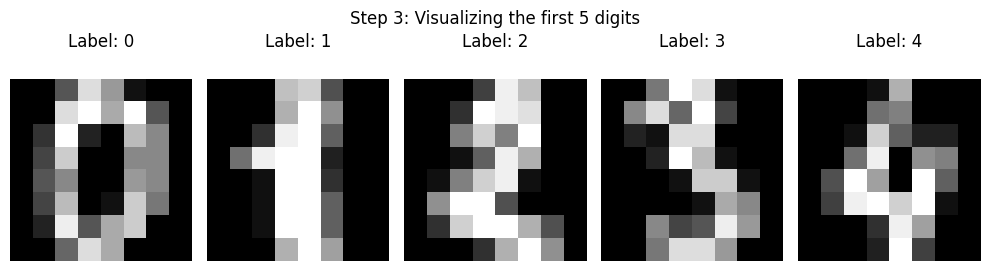

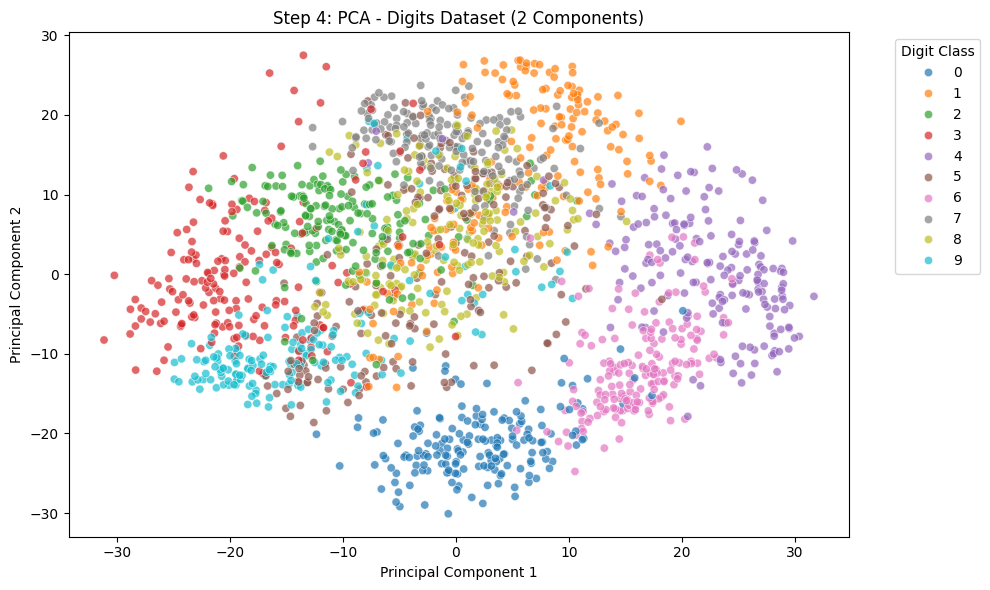

--- Step 5: Variance Analysis ---
Number of components needed to retain 90% of variance: 21


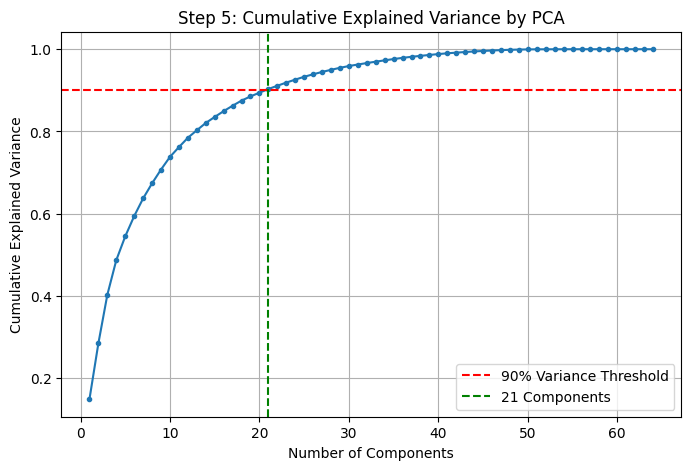

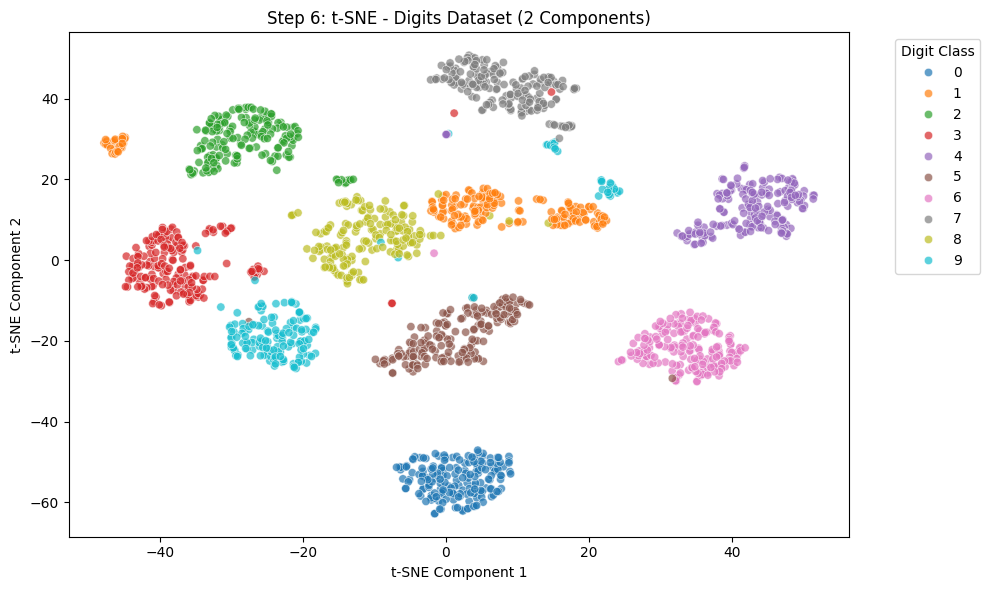

--- Step 7: Bonus (K-Means on t-SNE) ---


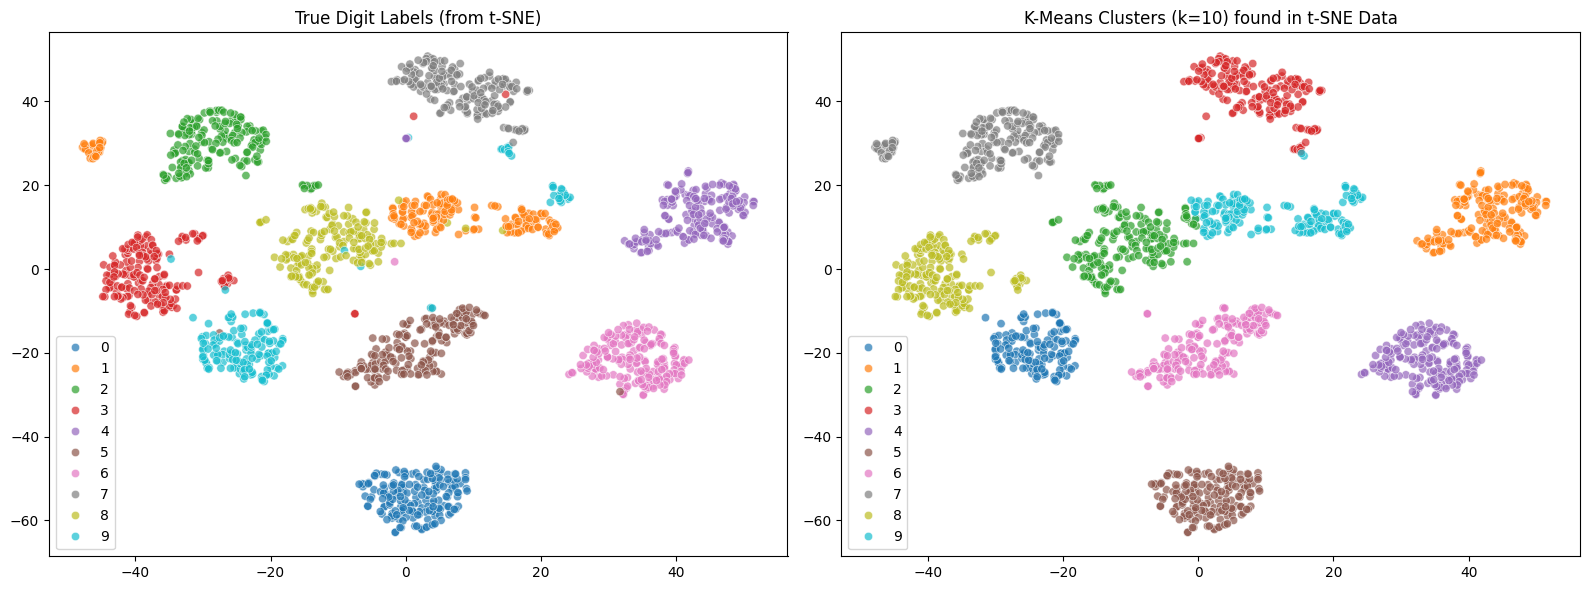

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ==========================================
# Steps 1 & 2: Load the Digits Dataset
# ==========================================
print("--- Steps 1 & 2: Loading Data ---")
digits = load_digits()
X = digits.data
y = digits.target

print(f"Data shape (X): {X.shape}") # Should be (1797, 64)
print(f"Target shape (y): {y.shape}")

# ==========================================
# Step 3: Visualize a few images
# ==========================================
# We create a 1x5 grid to show the first 5 handwritten digits
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].matshow(digits.images[i], cmap='gray')
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis('off')
plt.suptitle("Step 3: Visualizing the first 5 digits")
plt.tight_layout()
plt.show()

# ==========================================
# Step 4: Apply PCA (2 Components)
# ==========================================
# Reduce 64 dimensions down to 2
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', legend='full', alpha=0.7)
plt.title('Step 4: PCA - Digits Dataset (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Digit Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# Step 5: Explained Variance Analysis
# ==========================================
# Fit PCA on ALL 64 components to see how much variance each captures
pca_full = PCA(random_state=42)
pca_full.fit(X)

# Calculate cumulative sum of the variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find the number of components needed to reach 90% (0.90) variance
# np.argmax finds the first index where the condition is true. We add 1 because indices start at 0.
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"--- Step 5: Variance Analysis ---")
print(f"Number of components needed to retain 90% of variance: {components_90}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axvline(x=components_90, color='g', linestyle='--', label=f'{components_90} Components')
plt.title('Step 5: Cumulative Explained Variance by PCA')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# Step 6: Apply t-SNE (2 Components)
# ==========================================
# t-SNE is excellent for visualizing non-linear relationships
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab10', legend='full', alpha=0.7)
plt.title('Step 6: t-SNE - Digits Dataset (2 Components)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Digit Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# Step 7: Bonus - K-Means on t-SNE components
# ==========================================
print("--- Step 7: Bonus (K-Means on t-SNE) ---")
# We know there are 10 digits (0 through 9), so we set k=10
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
tsne_clusters = kmeans.fit_predict(X_tsne)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: True Labels
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab10', legend='full', alpha=0.7, ax=axes[0])
axes[0].set_title('True Digit Labels (from t-SNE)')

# Plot 2: K-Means Clusters
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=tsne_clusters, palette='tab10', legend='full', alpha=0.7, ax=axes[1])
axes[1].set_title('K-Means Clusters (k=10) found in t-SNE Data')

plt.tight_layout()
plt.show()